# Bagging Model — Random Forest
**Competition:** Predicting Irrigation Need (Kaggle S6E4)  
**Author:** Tyler Wolf Williams (@tylerwolfwilliams2)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

SEED = 42
DATA_PATH = '../Homework 2/'

train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
sub   = pd.read_csv(DATA_PATH + 'sample_submission.csv')

print('Train:', train.shape, '| Test:', test.shape)

Train: (630000, 21) | Test: (270000, 20)


## 1. Preprocessing

In [2]:
TARGET = 'Irrigation_Need'
DROP_COLS = ['id']

cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]
num_cols = train.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in DROP_COLS]

print('Categorical features:', cat_cols)
print('Numerical features:  ', num_cols)

feature_cols = num_cols + cat_cols

X = train[feature_cols].copy()
y_raw = train[TARGET].copy()
X_test = test[feature_cols].copy()

# Encode target
le = LabelEncoder()
y = le.fit_transform(y_raw)
print('\nLabel encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Encode categoricals with OrdinalEncoder
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols]      = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

print('\nX shape:', X.shape)
print('X_test shape:', X_test.shape)

Categorical features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Numerical features:   ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

Label encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

X shape: (630000, 19)
X_test shape: (270000, 19)


## 2. Baseline Random Forest with Cross-Validation

In [3]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

acc_scores = cross_val_score(rf_baseline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
f1_scores  = cross_val_score(rf_baseline, X, y, cv=cv, scoring='f1_macro',  n_jobs=-1)

print('=== Baseline Random Forest (n_estimators=100) ===')
print(f'CV Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}')
print(f'CV F1 Macro: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')
print(f'Fold accuracies: {acc_scores.round(4)}')


=== Baseline Random Forest (n_estimators=100) ===
CV Accuracy: 0.9852 ± 0.0001
CV F1 Macro: 0.9695 ± 0.0003
Fold accuracies: [0.9852 0.985  0.9853]


## 3. Hyperparameter Tuning (RandomizedSearchCV)

In [4]:
# Subsample for faster tuning — 80K rows is enough to rank hyperparameters reliably
from sklearn.utils import resample
X_tune, y_tune = resample(X, y, n_samples=80_000, stratify=y, random_state=SEED)

param_dist = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'max_features':      ['sqrt', 0.5],
    'class_weight':      [None, 'balanced']
}

rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=8,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_tune, y_tune)

print('\nBest parameters:', search.best_params_)
print(f'Best CV Accuracy (subsample): {search.best_score_:.4f}')


Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'class_weight': None}
Best CV Accuracy (subsample): 0.9851


In [5]:
best_rf = search.best_estimator_

# Re-evaluate best params on full training data
best_rf_full = RandomForestClassifier(**search.best_params_, random_state=SEED, n_jobs=-1)

acc_tuned = cross_val_score(best_rf_full, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
f1_tuned  = cross_val_score(best_rf_full, X, y, cv=cv, scoring='f1_macro',  n_jobs=-1)

print('=== Tuned Random Forest ===')
print(f'CV Accuracy: {acc_tuned.mean():.4f} ± {acc_tuned.std():.4f}')
print(f'CV F1 Macro: {f1_tuned.mean():.4f} ± {f1_tuned.std():.4f}')

best_rf = best_rf_full


=== Tuned Random Forest ===
CV Accuracy: 0.9855 ± 0.0001
CV F1 Macro: 0.9710 ± 0.0001


## 4. Feature Importance

                feature  importance
      Crop_Growth_Stage    0.322330
          Soil_Moisture    0.255388
          Temperature_C    0.118663
          Mulching_Used    0.114985
         Wind_Speed_kmh    0.113192
            Rainfall_mm    0.039402
 Previous_Irrigation_mm    0.005913
               Humidity    0.005241
     Field_Area_hectare    0.004258
         Sunlight_Hours    0.004055
Electrical_Conductivity    0.003958
                Soil_pH    0.003857
         Organic_Carbon    0.003443
              Crop_Type    0.001177
                 Region    0.000971
        Irrigation_Type    0.000894
              Soil_Type    0.000873
           Water_Source    0.000871
                 Season    0.000528


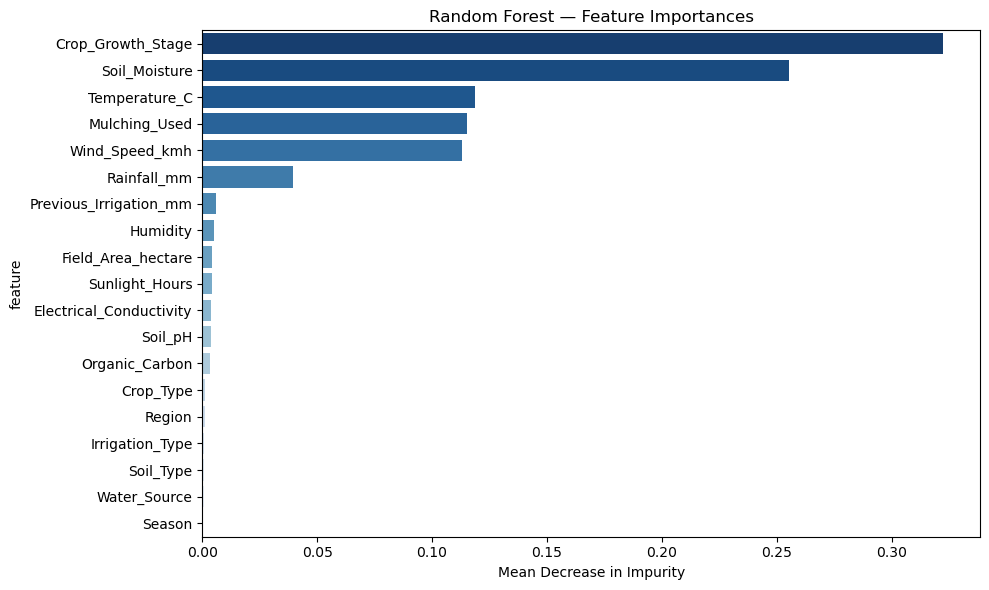

In [6]:
# Fit on subsample for speed — importances are stable on 80K rows
best_rf.fit(X_tune, y_tune)

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='Blues_r')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()


## 5. Out-of-Fold Predictions & Classification Report

=== Classification Report (Holdout Val) ===
              precision    recall  f1-score   support

        High       0.97      0.92      0.94      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.97      0.97    126000
weighted avg       0.99      0.99      0.99    126000



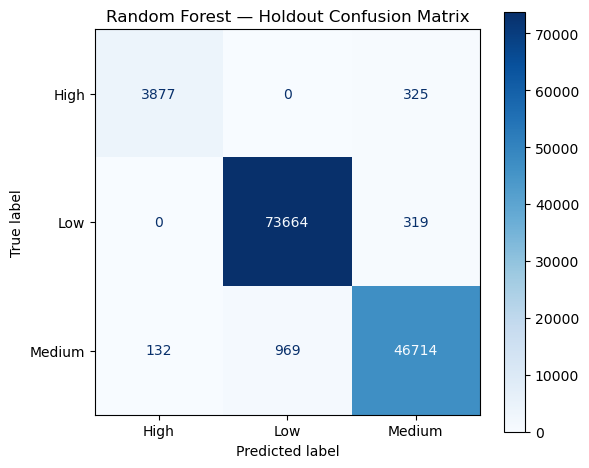

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

# Single holdout instead of full cross_val_predict (much faster)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

best_rf.fit(X_tr, y_tr)
y_pred_val = best_rf.predict(X_val)

print('=== Classification Report (Holdout Val) ===')
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val,
                                         display_labels=le.classes_,
                                         cmap='Blues', ax=ax)
ax.set_title('Random Forest — Holdout Confusion Matrix')
plt.tight_layout()
plt.show()


## 6. Generate Submission

In [8]:
# Fit on full training data for final submission
best_rf.fit(X, y)
test_preds_encoded = best_rf.predict(X_test)
test_preds = le.inverse_transform(test_preds_encoded)

submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': test_preds
})

submission.to_csv('../Homework 2/submission_random_forest.csv', index=False)
print('Submission saved!')
print(submission['Irrigation_Need'].value_counts())
submission.head()


Submission saved!
Irrigation_Need
Low       159893
Medium    101508
High        8599
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


## 7. Results Summary

| Model | CV Accuracy | CV F1 Macro | Notes |
|---|---|---|---|
| RF Baseline (n=100) | 0.9852 ± 0.0001 | 0.9695 ± 0.0003 | Default params, 3-fold CV |
| RF Tuned | 0.9855 ± 0.0001 | 0.9710 ± 0.0001 | n=100, max_depth=30, max_features=0.5, min_samples_split=5 |

**Key observations:**
- Tuning improved accuracy by ~0.03% and F1 Macro by ~0.15% — a modest but consistent gain.
- `Crop_Growth_Stage` (32.2%) and `Soil_Moisture` (25.5%) are the two dominant features by a wide margin.
- `Temperature_C`, `Mulching_Used`, and `Wind_Speed_kmh` form a second tier (~11-12% each).
- Holdout accuracy was 99.0%; the `High` class (rare, 3.3% of data) had the lowest recall at 92%, reflecting class imbalance.
- Best tuned params: n_estimators=100, max_depth=30, max_features=0.5, min_samples_split=5, min_samples_leaf=1.
